In [196]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # For PCA

# **Without PCA Knn**

In [197]:
df = pd.read_csv('train.csv')

In [198]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
13020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [199]:
df.shape

(42000, 785)

In [200]:
x = df.iloc[:,1:]
y = df.iloc[: ,0]

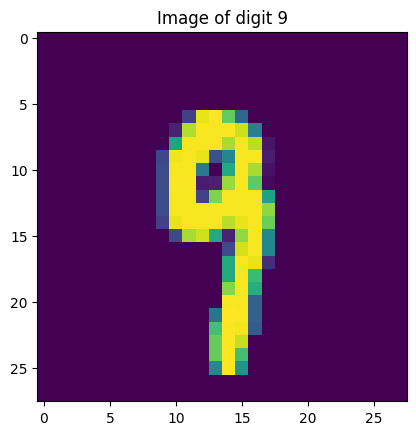

In [201]:
plt.imshow(df.iloc[20650,1:].values.reshape(28,28))
plt.title("Image of digit 9")
plt.show()

In [202]:
x_train , x_test , y_train ,y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [203]:
knn = KNeighborsClassifier()

knn.fit(x_train,y_train)

import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)



34.0028178691864


In [204]:
print(accuracy_score(y_test , y_pred))

0.9648809523809524


# **With PCA Knn**

In [205]:
StdScalar = StandardScaler()
x_train =StdScalar.fit_transform(x_train)
x_test = StdScalar.transform(x_test)

In [206]:
x_train.shape

(33600, 784)

In [207]:
PCA = PCA(n_components=200) # Change value of pca untill you got best result

In [208]:
x_train_trf = PCA.fit_transform(x_train)
x_test_trf = PCA.transform(x_test)

In [209]:
x_train_trf.shape

(33600, 200)

In [210]:
knn.fit(x_train_trf,y_train)

y_pred = knn.predict(x_test_trf)

In [211]:
print(accuracy_score(y_test , y_pred))

0.9507142857142857


 # Change value of pca untill you got best result

In [212]:
from sklearn.decomposition import PCA

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

best_accuracy = 0
best_component = 0

for i in range(21, 41):# We can change the loop range according to our features but in our case 784 features in our datasets so loop takes alot of time that why i use loop range  (1,21 ) And then after i dont get my acceptable accuracy i change loop range (21,41)

    Pca = PCA(n_components=i)

    x_train_trf = Pca.fit_transform(x_train)
    x_test_trf = Pca.transform(x_test)

    knn = KNeighborsClassifier()
    knn.fit(x_train_trf, y_train)

    y_pred = knn.predict(x_test_trf)

    accuracy = accuracy_score(y_test, y_pred)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_component = i

print("Best Accuracy:", best_accuracy)
print("Best Components:", best_component)


Best Accuracy: 0.9729761904761904
Best Components: 39


In [213]:
# After Gettting good component re training model 
pca1 = PCA(n_components=39)

x_train_trf = pca1.fit_transform(x_train)
x_test_trf = pca1.transform(x_test)

knn = KNeighborsClassifier()
knn.fit(x_train_trf, y_train)

y_pred = knn.predict(x_test_trf)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9729761904761904


## **How we can visualize this dataset into 2D And 3D**

In [214]:
# Transforming to a 2D Coordinate System
pca2 = PCA(n_components=2)
x_train_v = pca2.fit_transform(x_train)
x_test_v = pca2.transform(x_test)

In [215]:
x_train_v

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]], shape=(33600, 2))

In [240]:
import plotly.express as px

y_train_v = y_train.astype(str)

fig = px.scatter(
    x=x_train_v[:, 0],
    y=x_train_v[:, 1],
    color=y_train_v,
    color_discrete_sequence=px.colors.qualitative.G10,
    width=1200,
    height=800
)

fig.show()

# Transforming to a 3D Coordinate System

In [220]:
pca3 = PCA(n_components=3)
x_train_v3 = pca3.fit_transform(x_train)
x_test_v3 = pca3.transform(x_test)

In [221]:
import plotly.express as px
y_train_v3 = y_train.astype('str')
fig = px.scatter_3d(x=x_train_v3[:,0] , y = x_train_v3[:,1] , z = x_train_v3[:,2] , color = y_train_v , 
                    color_discrete_sequence=px.colors.qualitative.G10 , width=1400 , height= 600)

fig.show()


In [222]:
# Explained Variance 

pca3.explained_variance_

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [223]:
pca3.components_.shape

(3, 784)

# how We can take Otpimum  number of  Components

In [225]:
pca3.explained_variance_ratio_ # Automatically gives the percentage of Eigenvalues that showed how much varince is showed by it

array([0.09770722, 0.07129345, 0.06175413])

In [226]:
pca_Comp = PCA(n_components=None)
x_train_Comp = pca_Comp.fit_transform(x_train)
x_test_Comp = pca_Comp.transform(x_test)

In [229]:
pca_Comp.explained_variance_.shape # It shows because our all the feaatures /  compnents are there

(784,)

In [230]:
pca_Comp.components_.shape

(784, 784)

In [ ]:
pca_Comp.explained_variance_ratio_ # Automatically gives the percentage of Eigenvalues that showed how much varince is showed by it

array([9.77072202e-02, 7.12934512e-02, 6.17541312e-02, 5.38955140e-02,
       4.89255299e-02, 4.33684433e-02, 3.27657386e-02, 2.89270270e-02,
       2.77070300e-02, 2.32917149e-02, 2.09310651e-02, 2.04716403e-02,
       1.70779469e-02, 1.68320607e-02, 1.58472125e-02, 1.48798267e-02,
       1.32309818e-02, 1.28393670e-02, 1.18338358e-02, 1.15118647e-02,
       1.07596902e-02, 1.02421519e-02, 9.66625789e-03, 9.17296381e-03,
       8.84714420e-03, 8.33528008e-03, 8.15070612e-03, 7.75332066e-03,
       7.41986542e-03, 6.93325236e-03, 6.60848230e-03, 6.33209492e-03,
       6.03213006e-03, 5.88730096e-03, 5.61830060e-03, 5.39860932e-03,
       5.07909781e-03, 4.87126968e-03, 4.71252924e-03, 4.64556419e-03,
       4.52489910e-03, 4.44058540e-03, 4.16518263e-03, 3.95636411e-03,
       3.83603691e-03, 3.73127577e-03, 3.60704723e-03, 3.48865016e-03,
       3.34199674e-03, 3.18010732e-03, 3.14204894e-03, 3.07234334e-03,
       2.92367086e-03, 2.86553852e-03, 2.79118328e-03, 2.69328579e-03,
      

In [232]:
# Apply cumilative sum on it cumilative sum  adds all previous value with nect and give results 

np.cumsum(pca_Comp.explained_variance_ratio_)

array([0.09770722, 0.16900067, 0.2307548 , 0.28465032, 0.33357585,
       0.37694429, 0.40971003, 0.43863706, 0.46634409, 0.4896358 ,
       0.51056687, 0.53103851, 0.54811645, 0.56494851, 0.58079573,
       0.59567555, 0.60890653, 0.6217459 , 0.63357974, 0.6450916 ,
       0.65585129, 0.66609344, 0.6757597 , 0.68493267, 0.69377981,
       0.70211509, 0.7102658 , 0.71801912, 0.72543898, 0.73237223,
       0.73898072, 0.74531281, 0.75134494, 0.75723224, 0.76285054,
       0.76824915, 0.77332825, 0.77819952, 0.78291205, 0.78755761,
       0.79208251, 0.7965231 , 0.80068828, 0.80464464, 0.80848068,
       0.81221196, 0.815819  , 0.81930765, 0.82264965, 0.82582976,
       0.82897181, 0.83204415, 0.83496782, 0.83783336, 0.84062454,
       0.84331783, 0.84596712, 0.84853351, 0.85106204, 0.85351457,
       0.85592008, 0.85831105, 0.86057999, 0.86279635, 0.8649424 ,
       0.86700054, 0.86901774, 0.87098082, 0.87291702, 0.87479944,
       0.87665559, 0.87847316, 0.88022525, 0.88195105, 0.88360

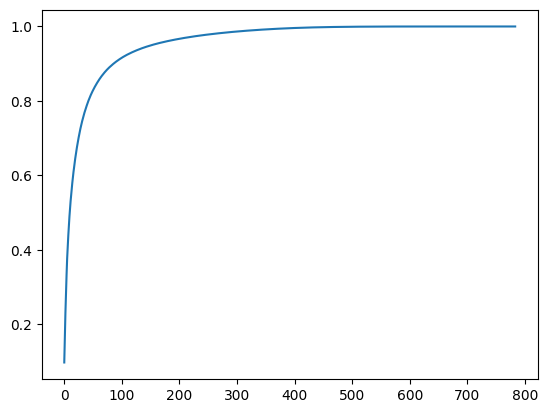

In [ ]:
# Now plot a graph on this data rather than manualy counting the pca components
plt.plot(np.cumsum(pca_Comp.explained_variance_ratio_))
plt.show() 

#  By graoh we clearly  seeing from x axis that  200  components shows the variance between (90% - 95%) of our data

In [239]:
Pca_Comp = PCA(n_components=200)

x_train_trf = Pca_Comp.fit_transform(x_train)
x_test_trf = Pca_Comp.transform(x_test)

knn = KNeighborsClassifier()
knn.fit(x_train_trf, y_train)

y_pred = knn.predict(x_test_trf)

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9675
